# How a Real AI Model Decides What Comes Next in Oilfield Text

You give an AI tool a partial sentence, and it predicts how to finish it. This notebook opens up a publicly available language model (the foundational technology behind modern AI assistants) to show you exactly what happens under the hood as it selects the next token, using actual drilling, completions, and well-intervention text.

Everything here runs locally on your machine: authentic industry sentences, a live model, and raw probabilities pulled directly from the network. Nothing is simulated, simplified, or scrubbed to look tidier than it is.

We start by looking at the model's output before unpacking the math and architecture behind it. The mechanics are easier to grasp once you see what they actually produce.

## What you'll be able to answer by the end

1. What does an AI model actually predict for a real oilfield sentence?
2. Why isn't its answer a whole word (what's a "token")?
3. Where do the percentages you see actually come from?
4. Why can changing a few words in a sentence completely change the
   model's answer?
5. Why can't a simple rule like "if it says POOH, it must mean X" replace
   this?
6. How is the way this model reads a word different from older "word
   vector" tools, where a word like "bit" always gets the same meaning?
7. Why shouldn't we say the model "understood" something, even when its
   answer looks smart?
8. What can we honestly say the model showed us, and what can't we claim
   to know?

A few technical terms will appear along the way, but each is explained in plain language with a practical example before we use it.
How the model turns these numbers into generated text (and deeper dives into the underlying architecture) are covered in later
notebooks.


## 1. What problem are we investigating?

Oilfield language is full of short, overloaded abbreviations. Take **POOH**
("pull out of hole"). It shows up during drilling, completions, workover,
intervention, wireline logging, coiled tubing cleanouts, and fishing jobs.
The word alone tells you almost nothing about what happens next in the
sentence — the *surrounding context* does.

That makes oilfield text a good, concrete way to show what an AI language
model is actually doing: it is not looking up "POOH" in a dictionary of
operations. It reads everything you've written so far and scores every
possible next word.

Here's the full journey a sentence takes through the model, in plain
terms — this is the order the model actually works in:

```
your sentence
    -> broken into small chunks ("tokens")
    -> the model scores every possible next chunk
    -> those scores become percentages
    -> we look at the top choices
```

In this notebook, though, we'll look at it in a more approachable order:
first see the model's real answer, then unpack each step of how it got
there.


## Installation (run once)

Uncomment and run the cell below the first time you use this notebook. You
do not need to run it every time — once the packages are installed, skip
it.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy gensim
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real AI model

We use **Qwen2.5-1.5B-Instruct**, a free, publicly available AI model small
enough to run on a normal laptop. The first time you run this notebook it
downloads once (about 3 GB) from the internet; after that, everything runs
on your own computer, with no internet connection needed.

> If this particular model can't load on your computer for any reason, the
> notebook automatically switches to a smaller backup model and clearly
> tells you which one it actually used.

The next code cell does some quiet computer setup — checking your
computer's hardware and making sure the results come out the same way
every time you run it. **You don't need to understand any of it; just run
it and move on.**


In [2]:
import random
import platform
import sys

import numpy as np
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
PRIMARY_MODEL_REVISION = "989aa7980e4cf806f80c7fef2b1adb7bc71aa306"  # pinned for reproducibility
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load
FALLBACK_MODEL_REVISION = "7ae557604adf67be50417f59c2c2f167def9a775"  # pinned for reproducibility

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# Half precision is only used on accelerated backends; CPU stays in float32 for numerical stability.
DTYPE = torch.float16 if DEVICE in ("mps", "cuda") else torch.float32

print(f"Python version:       {sys.version.split()[0]}")
print(f"Platform:             {platform.platform()}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
Platform:             macOS-27.0-arm64-arm-64bit
PyTorch version:      2.14.0
Transformers version: 5.16.1
Selected device:      mps
Selected dtype:       torch.float16


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model and its tokenizer onto the selected device.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    candidates = [(model_name, PRIMARY_MODEL_REVISION), (FALLBACK_MODEL_NAME, FALLBACK_MODEL_REVISION)]
    for i, (name, revision) in enumerate(candidates):
        try:
            tok = AutoTokenizer.from_pretrained(name, revision=revision)
            mdl = AutoModelForCausalLM.from_pretrained(name, revision=revision, dtype=DTYPE, use_safetensors=True)
            mdl.to(DEVICE)
            mdl.eval()
            return tok, mdl, name
        except Exception as exc:  # noqa: BLE001 - we want to report and fall back, not crash the notebook
            if i == len(candidates) - 1:
                raise
            print(f"Could not load '{name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")


tokenizer, model, MODEL_NAME = load_model()
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Vocabulary size: {model.config.vocab_size:,} tokens")



Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Vocabulary size: 151,936 tokens


## 3. A real oilfield sentence, left unfinished

Here's the sentence we'll use to start — notice it's deliberately cut off,
because we want to see what the model thinks comes next:

> "The crew pulled out of hole with the worn PDC bit and prepared to run a new"

We give the model this sentence exactly as written, with nothing extra
added before or after it — so what you see below is precisely what the
model receives, character for character. (Some AI chat tools quietly add
extra hidden instructions behind the scenes before your text reaches the
model; this notebook deliberately doesn't, to keep things transparent. The
technical notes at the very end say a little more about that, but it
doesn't matter for anything we're demonstrating here.)


In [4]:
PROMPT = "The crew pulled out of hole with the worn PDC bit and prepared to run a new"
print(repr(PROMPT))


'The crew pulled out of hole with the worn PDC bit and prepared to run a new'


## 4. What does the model actually predict next?

Let's just ask the real model and look at its answer. Exactly how it
arrives at these numbers is explained step by step in the next few
sections — for now, treat the function below as a black box that gives a
real, honest answer: real sentence in, real answer out. **You don't
need to understand any of it; just run it and move on.**


In [5]:
import pandas as pd


def show(df: pd.DataFrame):
    '''Display a table without pandas' default row-number column on the left, which isn't real data.'''
    display(df.style.hide(axis="index"))


def get_top_tokens(prompt: str, n: int = 15) -> pd.DataFrame:
    '''Ask the real model for the top-n candidate next words for `prompt`, with their real percentages.

    (Exactly how this works -- tokens, logits, softmax -- is explained in
    the next few sections. For now, this is just "ask the model, get an
    honest answer.")
    '''
    encoded = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**encoded)
    next_token_logits = outputs.logits[0, -1, :]
    next_token_probs = torch.softmax(next_token_logits, dim=-1)
    top_probs, top_ids = torch.topk(next_token_probs, n)

    rows = []
    for rank, (tid, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
        rows.append({
            "rank": rank,
            "token_id": tid,
            "decoded_token": repr(tokenizer.decode([tid])),
            "logit": next_token_logits[tid].item(),
            "probability": prob,
            "probability_percent": f"{prob * 100:.2f}%",
        })
    return pd.DataFrame(rows)


def simple_view(df: pd.DataFrame) -> pd.DataFrame:
    '''Return just the columns a first-time reader needs: rank, the word itself, and its probability.'''
    return df[["rank", "decoded_token", "probability_percent"]].rename(columns={
        "rank": "Rank",
        "decoded_token": "Next token",
        "probability_percent": "Probability",
    })


top_tokens_main = get_top_tokens(PROMPT, n=15)
show(simple_view(top_tokens_main))


Rank,Next token,Probability
1,' bit',33.52%
2,' one',27.78%
3,' P',7.48%
4,' ',2.51%
5,' drill',1.98%
6,' tool',1.45%
7,' diamond',1.30%
8,"','",1.22%
9,' well',0.43%
10,' set',0.42%


**What this shows:** this table is the model's honest answer for
the sentence above. If the top candidate isn't an intuitive oilfield word —
it might be punctuation or a small grammatical filler — that's a real,
expected part of how these models work, not an error we're hiding.
Whatever appears above is exactly what the real model produced.


### Seeing it as a chart

The same real answer, as a simple bar chart — the longer the bar, the
higher the percentage. **You don't need to understand the plotting
code below; just run it and move on.**


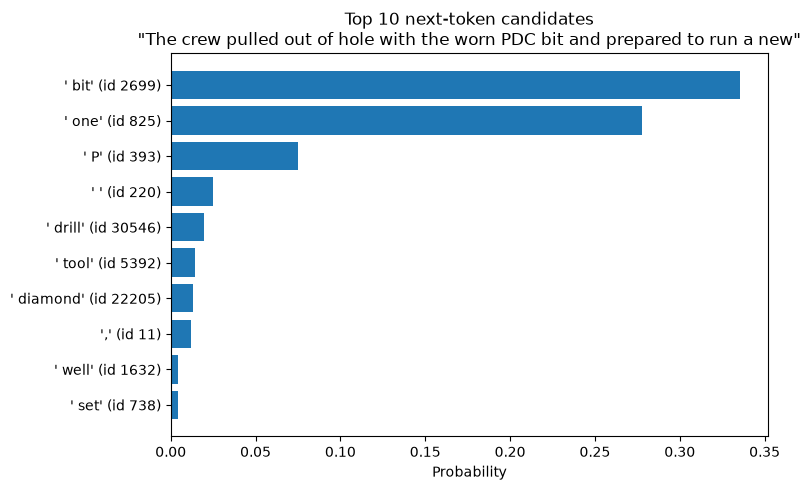

In [6]:
import matplotlib.pyplot as plt


def plot_top_tokens(df: pd.DataFrame, title: str, top_n: int = 10):
    plot_df = df.head(top_n).iloc[::-1]  # reverse so rank 1 appears at the top of the chart
    labels = [f"{row.decoded_token} (id {row.token_id})" for row in plot_df.itertuples()]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(labels, plot_df["probability"])
    ax.set_xlabel("Probability")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


plot_top_tokens(top_tokens_main, f'Top 10 next-token candidates\n"{PROMPT}"')


Two natural questions from that table: *why is the answer a
fragment like `' P'` instead of a whole word sometimes, and where do these
percentages actually come from?* The next two sections answer exactly
that.


## 5. Why are these "tokens," not whole words?

An AI language model doesn't actually read whole words. It reads
**tokens** — small chunks of text, each represented by a number. A token
can be:

- a whole word (`' bit'`)
- part of a word (`'ing'`)
- punctuation
- a space attached to the front of a word (`' the'` — note the leading space)
- a number or technical fragment

This matters a lot for oilfield text, because domain terms and acronyms
often do **not** map to a single token — they get split into pieces. Below,
we print each piece with quote marks around it (`repr()`) so a leading
space is visible instead of silently disappearing.


In [7]:
def tokenize_prompt(prompt: str):
    '''Tokenize a prompt and return (input_ids tensor, list of decoded token strings).'''
    encoded = tokenizer(prompt, return_tensors="pt")
    input_ids = encoded["input_ids"][0]
    decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids]
    return encoded, input_ids, decoded_tokens


encoded, input_ids, decoded_tokens = tokenize_prompt(PROMPT)

token_table = pd.DataFrame({
    "position": range(len(input_ids)),
    "token_id": input_ids.tolist(),
    "decoded_token": [repr(t) for t in decoded_tokens],
})
print(f"The prompt was split into {len(input_ids)} tokens.\n")
show(token_table)


The prompt was split into 18 tokens.



position,token_id,decoded_token
0,785,'The'
1,13627,' crew'
2,13238,' pulled'
3,700,' out'
4,315,' of'
5,14178,' hole'
6,448,' with'
7,279,' the'
8,23704,' worn'
9,393,' P'


**What this shows:** some familiar oilfield words split into more
than one piece, and most word-pieces carry a leading space (that's how the
model marks "a new word started here"). This is the real, unedited output
for the real sentence above — nothing here is made up for illustration.


### 5a. Oilfield terms are often split into several pieces

Let's check how the model handles common oilfield vocabulary. A term being
split into several pieces isn't a sign the model "doesn't understand" it —
it just means the term wasn't common enough in the huge amount of text the
model originally learned from to earn its own single piece. Don't read
more into the piece count than that.


In [8]:
oilfield_terms = [
    "completion", "perforation", "coiled tubing", "wellbore", "PDC",
    "BHA", "SCSSV", "ESP", "packer", "fracturing", "POOH", "RIH", "TCP",
]

def tokenize_term(term: str):
    ids = tokenizer.encode(term, add_special_tokens=False)
    pieces = [tokenizer.decode([tid]) for tid in ids]
    return ids, pieces

term_rows = []
for term in oilfield_terms:
    ids, pieces = tokenize_term(term)
    term_rows.append({
        "term": term,
        "num_pieces": len(ids),
        "token_ids": ids,
        "decoded_pieces": [repr(p) for p in pieces],
    })

term_table = pd.DataFrame(term_rows)
show(term_table)


term,num_pieces,token_ids,decoded_pieces
completion,1,[43312],"[""'completion'""]"
perforation,3,"[712, 1958, 367]","[""'per'"", ""'for'"", ""'ation'""]"
coiled tubing,3,"[1015, 2181, 73902]","[""'co'"", ""'iled'"", ""' tubing'""]"
wellbore,3,"[9157, 65, 460]","[""'well'"", ""'b'"", ""'ore'""]"
PDC,2,"[47, 5626]","[""'P'"", ""'DC'""]"
BHA,2,"[33, 17020]","[""'B'"", ""'HA'""]"
SCSSV,3,"[3540, 1220, 53]","[""'SC'"", ""'SS'"", ""'V'""]"
ESP,1,[56229],"[""'ESP'""]"
packer,2,"[4748, 261]","[""'pack'"", ""'er'""]"
fracturing,3,"[1626, 531, 1677]","[""'fr'"", ""'act'"", ""'uring'""]"


## 6. Where did these percentages actually come from?

Now let's open up the black box from Section 4. We'll redo the same
calculation by hand, one real step at a time, using the same sentence.

First, we hand the tokenized sentence to the model and ask it one
question: *given everything so far, how do you score every single piece of
text that could come next?*

The model answers with one score for **every single entry in its
vocabulary** — about 150,000 scores in total, covering every possible next
piece, even the ones that would make no sense at all. We only care about
the scores for the very last position in our sentence, since that's where
the next word will go.

> **If you're comfortable reading code:** `outputs.logits[0, -1, :]` below
> pulls out exactly that list of ~150,000 scores. If you're not, that's
> completely fine — the only thing that matters is: *the model scores
> every possible next piece, all at once, for our exact sentence.*


In [9]:
encoded = encoded.to(DEVICE)

with torch.no_grad():
    outputs = model(**encoded)

logits = outputs.logits  # shape: (batch, sequence_length, vocab_size)
next_token_logits = logits[0, -1, :]

print(f"Full logits tensor shape:  {tuple(logits.shape)}")
print(f"Next-token logits shape:   {tuple(next_token_logits.shape)}")
assert next_token_logits.shape[0] == model.config.vocab_size, (
    "Sanity check: the next-token logits vector should have one entry per vocabulary token."
)
print("Sanity check passed: one logit per vocabulary token.")


Full logits tensor shape:  (1, 18, 151936)
Next-token logits shape:   (151936,)
Sanity check passed: one logit per vocabulary token.


### What is a "logit"? (a raw score, not yet a percentage)

A **logit** is just the model's raw score for one token — how much it
favors that token as the next one, before that score gets turned into
something like a percentage. Logits can be any number: negative, positive,
small, or large. On their own they don't mean much except relative to each
other — a bigger logit simply means "the model liked this one more."

Below are the model's real, raw scores for a handful of plausible oilfield
words, read directly out of the model for this exact sentence — no numbers
here are invented.


In [10]:
def first_token_id(word_with_space: str) -> int:
    '''Return the token ID for the first token produced when encoding a word (with its leading space).'''
    return tokenizer.encode(word_with_space, add_special_tokens=False)[0]


candidate_words = [" bit", " liner", " BHA", " string", " packer", " logging"]
candidate_ids = {word: first_token_id(word) for word in candidate_words}

logit_rows = []
for word, tid in candidate_ids.items():
    logit_rows.append({
        "word": word,
        "token_id": tid,
        "logit": next_token_logits[tid].item(),
    })

logit_table = pd.DataFrame(logit_rows).sort_values("logit", ascending=False).reset_index(drop=True)
show(logit_table)


word,token_id,logit
bit,2699,19.906250
string,914,14.992188
BHA,425,14.750000
liner,52988,14.367188
packer,3769,14.218750
logging,8392,9.796875


A higher logit means the model favored that word more as a
continuation — but these numbers aren't percentages yet. Turning them into
percentages is exactly what's next.

### Turning raw scores into percentages you can actually compare

Raw scores are hard to compare directly — a score of 19.9 doesn't obviously
mean "twice as likely" as a score of 9.9. **Softmax** is the standard math
trick that turns a whole list of raw scores into real percentages that all
add up to 100% — so you can finally say "the model gives this word a 33%
chance."

It works by favoring bigger scores more and more steeply, then scaling
everything down so the whole list adds up to 1 (100%). Crucially, that
"adds up to 100%" only works if you do it across **every single one of the
~150,000 possible tokens** — not just a handful of favorites. We do exactly
that below, using the real scores above.

> **For the curious:** softmax has a precise mathematical formula
> ($P_i = e^{z_i} / \sum_j e^{z_j}$), but you don't need it to follow the
> rest of this notebook — the plain description above is all that matters
> here.


In [11]:
# The real distribution: softmax over the FULL vocabulary logits.
next_token_probs = torch.softmax(next_token_logits, dim=-1)

prob_sum = next_token_probs.sum().item()
print(f"Sum of probabilities over the full vocabulary: {prob_sum:.6f}")
assert abs(prob_sum - 1.0) < 1e-3, "Softmax output should sum to (approximately) 1."
print("Sanity check passed: softmax over the full vocabulary sums to ~1.")


Sum of probabilities over the full vocabulary: 0.999512
Sanity check passed: softmax over the full vocabulary sums to ~1.


In [12]:
# ILLUSTRATIVE ONLY: applying softmax to just the small subset of words from above.
# This does NOT give the true vocabulary probabilities for these words (their true
# probabilities already come from `next_token_probs` above, computed over the full
# vocabulary). This cell exists only to show the softmax arithmetic on numbers small
# enough to read by eye.
illustration_table = logit_table.copy()
subset_logits = torch.tensor(illustration_table["logit"].tolist())
subset_softmax_illustration = torch.softmax(subset_logits, dim=-1)

illustration_table["illustrative_percent"] = subset_softmax_illustration.numpy()
illustration_table["real_percent"] = [
    next_token_probs[tid].item() for tid in illustration_table["token_id"]
]
show(illustration_table)


word,token_id,logit,illustrative_percent,real_percent
bit,2699,19.906250,0.979946,0.335205
string,914,14.992188,0.007195,0.002462
BHA,425,14.750000,0.005648,0.001932
liner,52988,14.367188,0.003851,0.001318
packer,3769,14.218750,0.003320,0.001136
logging,8392,9.796875,0.000040,0.000014


**What this shows:** the two percentage columns above are usually
quite different. That's the whole point — turning a small, hand-picked
group of words into percentages that add up to 100% is not the same as the
model's real answer, which only comes from doing this across the *entire*
vocabulary at once. The right-hand column, "real_percent," is the real one.

### Now the full picture

You've seen the simple version of the top-candidates table in Section 4,
and now you know exactly what a token ID and a logit are. Here's that same
real result again, this time with every column shown.


In [13]:
show(top_tokens_main)


rank,token_id,decoded_token,logit,probability,probability_percent
1,2699,' bit',19.906250,0.335205,33.52%
2,825,' one',19.718750,0.277832,27.78%
3,393,' P',18.406250,0.074829,7.48%
4,220,' ',17.312500,0.025055,2.51%
5,30546,' drill',17.078125,0.019821,1.98%
6,5392,' tool',16.765625,0.014503,1.45%
7,22205,' diamond',16.656250,0.013000,1.30%
8,11,"','",16.593750,0.012215,1.22%
9,1632,' well',15.554688,0.004322,0.43%
10,738,' set',15.531250,0.004219,0.42%


## 7. How "sure" is the model? (a simple uncertainty score)

Sometimes the model puts almost all its weight on one or two words; other
times it spreads its bets thinly across many options. **Entropy** is a
single number that captures that:

- **Lower entropy** → the model is fairly concentrated on a small set of
  likely words.
- **Higher entropy** → the model sees many roughly-equally-plausible
  options.

One important caution: entropy only tells you how *spread out* the
model's guesses are. It says **nothing** about whether the model's top
guess is actually correct in the real world.

> **For the curious:** entropy has a standard formula
> ($H = -\sum_i p_i \log p_i$), but you can follow everything below just by
> knowing "lower number = more concentrated, higher number = more spread
> out."


In [14]:
def get_next_token_distribution(prompt: str):
    '''Run `prompt` through the model and return (input_ids, logits, probabilities) for the next token.'''
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc)
    logits_vec = out.logits[0, -1, :]
    probs_vec = torch.softmax(logits_vec, dim=-1)
    return enc["input_ids"][0], logits_vec, probs_vec


def calculate_entropy(probabilities: torch.Tensor) -> float:
    '''Shannon entropy (natural log, in nats) of a probability distribution tensor.'''
    # Cast to float32 before clamping: on MPS/CUDA the model runs in float16, whose
    # smallest representable positive value is far larger than 1e-12, so clamping in
    # float16 would silently round tiny probabilities to exactly 0 and produce NaN.
    p = probabilities.float().clamp_min(1e-12)
    return float(-(p * p.log()).sum().item())


_, _, probs_main = get_next_token_distribution(PROMPT)
entropy_main = calculate_entropy(probs_main)
print(f"Uncertainty score (entropy) for the main prompt: {entropy_main:.3f}")


Uncertainty score (entropy) for the main prompt: 3.108


## 8. Does changing the sentence change the prediction?

This is the core oilfield lesson. Below are several related, realistic
prompts. For each one we compute the model's real top-10 answers and its
uncertainty score, then compare them side by side. We don't assume in
advance what any of them should predict — we just look at what the real
model says.

- **A:** "The crew pulled out of hole"
- **B:** "The crew pulled out of hole with the worn PDC bit"
- **C:** "The crew pulled out of hole with the worn PDC bit and prepared to run a new" (our main prompt)
- **D:** "The crew pulled out of hole with the production logging tool and prepared to run a new"
- **E:** "The crew pulled out of hole after milling the bridge plug and prepared to run a"
- **F:** "The crew pulled out of hole after reaching section TD and prepared to run a new"


In [15]:
context_prompts = {
    "A": "The crew pulled out of hole",
    "B": "The crew pulled out of hole with the worn PDC bit",
    "C": "The crew pulled out of hole with the worn PDC bit and prepared to run a new",
    "D": "The crew pulled out of hole with the production logging tool and prepared to run a new",
    "E": "The crew pulled out of hole after milling the bridge plug and prepared to run a",
    "F": "The crew pulled out of hole after reaching section TD and prepared to run a new",
}

def compare_prompts(prompts: dict, n: int = 10):
    '''Compute top-n next-token tables and entropy for each named prompt.'''
    tables = {}
    summary_rows = []
    for name, text in prompts.items():
        df = get_top_tokens(text, n=n)
        tables[name] = df
        _, _, probs = get_next_token_distribution(text)
        summary_rows.append({
            "Label": name,
            "Sentence": text,
            "Top pick": df.iloc[0]["decoded_token"],
            "Probability": df.iloc[0]["probability_percent"],
            "Uncertainty score": calculate_entropy(probs),
        })
    return tables, pd.DataFrame(summary_rows)


context_tables, context_summary = compare_prompts(context_prompts, n=10)
show(context_summary)


Label,Sentence,Top pick,Probability,Uncertainty score
A,The crew pulled out of hole,' ',20.13%,4.055666
B,The crew pulled out of hole with the worn PDC bit,' and',17.72%,3.834699
C,The crew pulled out of hole with the worn PDC bit and prepared to run a new,' bit',33.52%,3.108176
D,The crew pulled out of hole with the production logging tool and prepared to run a new,' tool',25.88%,3.593982
E,The crew pulled out of hole after milling the bridge plug and prepared to run a,' cement',8.07%,5.329631
F,The crew pulled out of hole after reaching section TD and prepared to run a new,' section',18.01%,4.914478


In [16]:
for label in context_prompts:
    print(f"--- Prompt {label}: {context_prompts[label]!r} ---")
    show(simple_view(context_tables[label].head(5)))


--- Prompt A: 'The crew pulled out of hole' ---


Rank,Next token,Probability
1,' ',20.13%
2,' #',8.80%
3,' number',7.18%
4,' after',6.96%
5,' in',6.14%


--- Prompt B: 'The crew pulled out of hole with the worn PDC bit' ---


Rank,Next token,Probability
1,' and',17.72%
2,'.',15.88%
3,"','",10.42%
4,' in',5.94%
5,'.\n',4.70%


--- Prompt C: 'The crew pulled out of hole with the worn PDC bit and prepared to run a new' ---


...

Rank,Next token,Probability
1,' tool',25.88%
2,' one',21.45%
3,' hole',6.54%
4,' well',3.91%
5,' job',2.86%


--- Prompt E: 'The crew pulled out of hole after milling the bridge plug and prepared to run a' ---


Rank,Next token,Probability
1,' cement',8.07%
2,' ',5.29%
3,' casing',3.76%
4,' new',3.42%
5,' _____',3.42%


--- Prompt F: 'The crew pulled out of hole after reaching section TD and prepared to run a new' ---


Rank,Next token,Probability
1,' section',18.01%
2,' hole',13.81%
3,' line',5.08%
4,' route',3.08%
5,' string',2.89%


**What this shows:** look at the model's top pick and uncertainty
score for each version, A through F. Sentences that end mid-thought, with
less context, tend to show a different (often higher) uncertainty score
than sentences that give the model a fuller picture — but read the actual
numbers above rather than assuming this pattern; the real output is what
matters, not our expectation of it.


## 9. "POOH" alone is ambiguous

**POOH** ("pull out of hole") is not tied to a single kind of job. It shows
up in drilling, completions, workover, well intervention, wireline
logging, coiled tubing cleanouts, and fishing jobs. So:

> POOH does not mean one specific operation

The sentences below all start with POOH but describe very different jobs.
We compute the real answer for each one and compare — this is not a lookup
table that maps "POOH" to a category, it's five separate, independent
questions to the real model.


In [17]:
pooh_prompts = {
    "drilling":     "POOH with worn PDC bit after drilling to section TD, then prepared to run a",
    "perforating":  "POOH with TCP guns after perforating, then prepared to run a",
    "logging":      "POOH with production logging tool after completing the survey, then prepared to run a",
    "cleanout":     "POOH with coiled tubing cleanout BHA, then prepared to run a",
    "fishing":      "POOH with fishing assembly after recovering the fish, then prepared to run a",
}

pooh_tables, pooh_summary = compare_prompts(pooh_prompts, n=10)
show(pooh_summary)


Label,Sentence,Top pick,Probability,Uncertainty score
drilling,"POOH with worn PDC bit after drilling to section TD, then prepared to run a",' ',25.61%,5.260157
perforating,"POOH with TCP guns after perforating, then prepared to run a",' ',11.98%,6.648560
logging,"POOH with production logging tool after completing the survey, then prepared to run a",' production',8.56%,5.777425
cleanout,"POOH with coiled tubing cleanout BHA, then prepared to run a",' ',19.09%,5.390667
fishing,"POOH with fishing assembly after recovering the fish, then prepared to run a",' fishing',4.80%,6.642743


**What this shows:** the word "POOH" is identical across all five
sentences; only the surrounding job details differ. Any differences you
see in the model's top pick or uncertainty score above come entirely from
that surrounding context — the model is reading the whole sentence, not
just reacting to one keyword.


## 10. Removing words one at a time: how much context is enough?

Starting from our main prompt, we progressively strip words away and watch
how the model's answer and uncertainty score change.

- **Full:** "The crew pulled out of hole with the worn PDC bit and prepared to run a new"
- **Version 1:** "Pulled out of hole with the worn PDC bit and prepared to run a new"
- **Version 2:** "Pulled out of hole with the PDC bit and prepared to run a new"
- **Version 3:** "Pulled out of hole and prepared to run a new"
- **Version 4:** "Prepared to run a new"


In [18]:
ablation_prompts = {
    "Full":       "The crew pulled out of hole with the worn PDC bit and prepared to run a new",
    "Version 1":  "Pulled out of hole with the worn PDC bit and prepared to run a new",
    "Version 2":  "Pulled out of hole with the PDC bit and prepared to run a new",
    "Version 3":  "Pulled out of hole and prepared to run a new",
    "Version 4":  "Prepared to run a new",
}

ablation_tables, ablation_summary = compare_prompts(ablation_prompts, n=10)
show(ablation_summary)


Label,Sentence,Top pick,Probability,Uncertainty score
Full,The crew pulled out of hole with the worn PDC bit and prepared to run a new,' bit',33.52%,3.108176
Version 1,Pulled out of hole with the worn PDC bit and prepared to run a new,' bit',32.67%,3.082119
Version 2,Pulled out of hole with the PDC bit and prepared to run a new,' bit',15.83%,4.697844
Version 3,Pulled out of hole and prepared to run a new,' well',5.00%,6.200665
Version 4,Prepared to run a new,' business',5.37%,6.794231


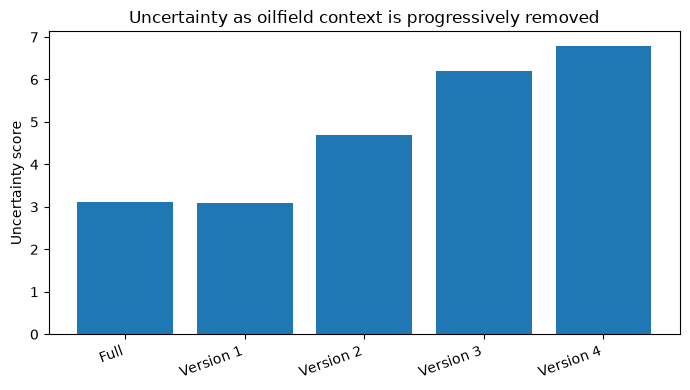

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ablation_summary["Label"], ablation_summary["Uncertainty score"])
ax.set_ylabel("Uncertainty score")
ax.set_title("Uncertainty as oilfield context is progressively removed")
ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_ha("right")
fig.tight_layout()
plt.show()


**What this shows:** each bar's height is the model's real
uncertainty score for that shortened sentence — read the values rather
than assuming uncertainty must always increase as context disappears;
report what the chart actually shows, not what seems intuitive.


## 11. Why not just use a simple keyword rule?

It would be tempting to write a simple rule like: *"whenever the text
contains the word POOH, always guess 'Well Intervention' — no matter what
else the sentence says."*

This rule is intentionally too simple, and it's **not** used anywhere in
the real model calculations above — it's here only to contrast with what
the model actually does. Let's check it against the five POOH sentences
from Section 9.


In [20]:
def naive_keyword_rule(text: str) -> str:
    '''Deliberately oversimplified classifier, included only to show why context matters.'''
    return "Well Intervention" if "POOH" in text else "Unclassified"

for label, text in pooh_prompts.items():
    rule_guess = naive_keyword_rule(text)
    print(f"[{label:11s}] rule says: {rule_guess:18s} | actual job: {label}")


[drilling   ] rule says: Well Intervention  | actual job: drilling
[perforating] rule says: Well Intervention  | actual job: perforating
[logging    ] rule says: Well Intervention  | actual job: logging
[cleanout   ] rule says: Well Intervention  | actual job: cleanout
[fishing    ] rule says: Well Intervention  | actual job: fishing


**What this shows:** the simple rule gives the exact same answer
("Well Intervention") for every sentence, whether the job was drilling,
perforating, logging, a cleanout, or fishing — because it only ever looks
at one keyword. The real model, by contrast, reads the entire sentence and
gave measurably different answers for each one (Section 9). That's the
difference between matching one keyword and actually reading context.


### 11a. A smarter keyword rule? Older "word vectors" (with Gensim)

Before today's AI models, a popular idea (from around 2013–2014, with
tools called *word2vec* and *GloVe*) was to learn **one list of numbers per
word** from a huge amount of text. That list of numbers is called a *word
vector*. Words that tend to appear in similar places get similar vectors,
so these tools can tell you which words are "close" to each other.

That's much smarter than the keyword rule above. But it has the same basic
limit: **each word gets exactly one vector**, no matter which sentence it
appears in. "Bit" gets one fixed vector, whether it's a PDC bit or "a
little bit".

Below we load a real, publicly available set of these vectors (GloVe,
learned from Wikipedia and news articles) using a Python library called
**Gensim**, and ask it which words are closest to a few oilfield terms.

> **Important:** the numbers in the next two code cells come from GloVe, a
> different and much simpler model, **not** from the Qwen model used
> everywhere else in this notebook. The first run downloads about
> 128 MB of GloVe vectors; after that they're loaded from your computer.

In [21]:
try:
    import gensim.downloader
except ImportError:  # e.g. a fresh Colab session: install Gensim once, then carry on
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "gensim"])
    import gensim.downloader

GLOVE_NAME = "glove-wiki-gigaword-100"  # public GloVe word vectors, downloaded once, then cached
glove = gensim.downloader.load(GLOVE_NAME)  # these vectors are GloVe's, NOT the Qwen model's
print(f"Loaded {GLOVE_NAME}: {len(glove.key_to_index):,} words, {glove.vector_size} numbers per word")

glove_words = ["bit", "fishing", "packer", "wireline", "pooh"]  # GloVe only knows lowercase words
show(pd.DataFrame({
    "Oilfield word": glove_words,
    "GloVe's 5 closest words (its one and only answer)": [
        ", ".join(neighbor for neighbor, _ in glove.most_similar(word, topn=5)) for word in glove_words
    ],
}))

Loaded glove-wiki-gigaword-100: 400,000 words, 100 numbers per word


Oilfield word,GloVe's 5 closest words (its one and only answer)
bit,"little, pretty, too, quite, lot"
fishing,"fishermen, boats, boat, trawlers, boating"
packer,"murdoch, pbl, mackay, turner, burley"
wireline,"landline, fixed-line, wireless, telephony, broadband"
pooh,"tigger, poohed, piglet, winnie, eeyore"


**What this shows:** GloVe's closest words come from how these words are
used in everyday English, not on a rig. "Bit" sits next to words like
"little" and "pretty", "fishing" next to boats and fishermen, "packer"
next to surnames such as "murdoch", "wireline" next to landlines and broadband, and
"pooh" next to Winnie-the-Pooh's friends. None of that is *wrong* for
general English. But it's the only answer GloVe can ever give, because
each word has only one vector.

We can also draw these vectors as a map. Each word's 100 numbers are
squashed down to 2 so they fit on a flat chart (a standard technique called
PCA). The two axes don't have a meaning of their own; only which words sit
near each other matters.

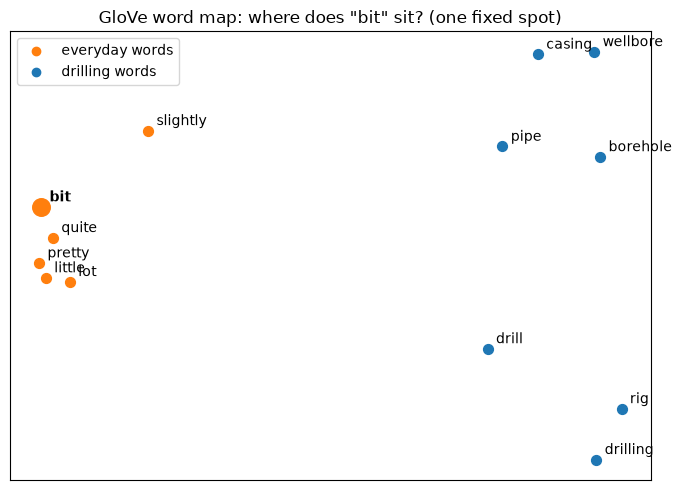

In [22]:
def flatten_to_2d(vectors: np.ndarray) -> np.ndarray:
    '''Squash each high-dimensional vector down to 2 numbers for plotting (PCA, computed with numpy).'''
    centered = vectors - vectors.mean(axis=0)
    _, _, directions = np.linalg.svd(centered, full_matrices=False)
    return centered @ directions[:2].T


everyday_words = ["bit", "little", "pretty", "quite", "lot", "slightly"]
drilling_words = ["drill", "drilling", "rig", "pipe", "casing", "borehole", "wellbore"]
map_words = everyday_words + drilling_words
map_points = flatten_to_2d(np.stack([glove[word] for word in map_words]))

fig, ax = plt.subplots(figsize=(7, 5))
for (x, y), word in zip(map_points, map_words):
    color = "tab:orange" if word in everyday_words else "tab:blue"
    ax.scatter(x, y, color=color, s=160 if word == "bit" else 50)
    ax.annotate(word, (x, y), xytext=(6, 4), textcoords="offset points",
                fontweight="bold" if word == "bit" else "normal")
ax.scatter([], [], color="tab:orange", label="everyday words")
ax.scatter([], [], color="tab:blue", label="drilling words")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('GloVe word map: where does "bit" sit? (one fixed spot)')
fig.tight_layout()
plt.show()

**Now the real model.** The Qwen model also starts by giving each token
one fixed vector (its very first step). But then, layer after layer, it
mixes in information from the surrounding words, so the vector it holds
for a word *changes with the sentence*.

We can read those inside vectors directly. Below, we give the model eight
short sentences that all end in the word "bit": four about drilling, four
everyday ones. The sentences were written for this demonstration. For each
one, we read the model's internal vector for "bit" from its middle layer,
then compare them.

Every sentence *ends* with "bit" on purpose: this model reads left to
right, so its vector for a word can only reflect the words that came
*before* it.

Read 8 vectors for "bit" from layer 14 of 28, 1,536 numbers each.


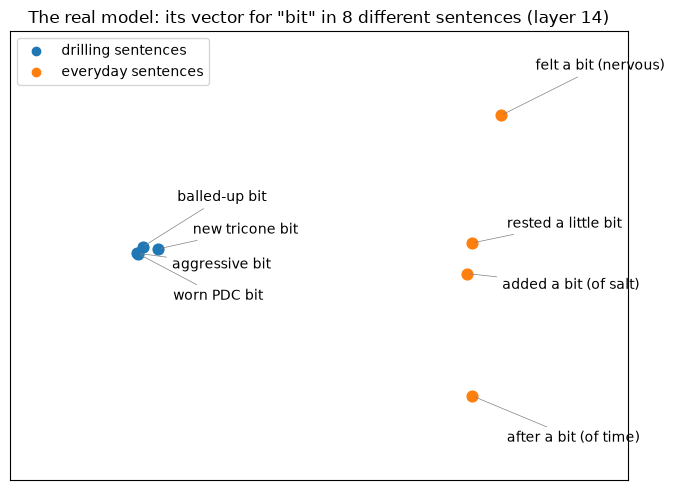

"Comparing ""bit"" in...",Average similarity (1.0 = identical)
two drilling sentences,0.86
two everyday sentences,0.67
a drilling vs. an everyday sentence,0.44


In [23]:
bit_sentences = [
    ("drilling", "worn PDC bit",           "The crew pulled out of hole with the worn PDC bit"),
    ("drilling", "balled-up bit",          "Rate of penetration dropped sharply, so the driller suspected a balled-up bit"),
    ("drilling", "new tricone bit",        "After drilling the shoe track they ran in hole with a new tricone bit"),
    ("drilling", "aggressive bit",         "The directional driller picked a steerable motor and an aggressive bit"),
    ("everyday", "rested a little bit",    "I was tired after the long drive, so I rested a little bit"),
    ("everyday", "added a bit (of salt)",  "The soup needed more salt, so she added a bit"),
    ("everyday", "felt a bit (nervous)",   "He was nervous before the interview and felt a bit"),
    ("everyday", "after a bit (of time)",  "The movie started slowly but got better after a bit"),
]
MIDDLE_LAYER = model.config.num_hidden_layers // 2


def vector_for_last_word(sentence: str, layer: int = MIDDLE_LAYER) -> np.ndarray:
    '''The model's internal vector for the sentence's last token, read at one layer.'''
    encoded = tokenizer(sentence, return_tensors="pt").to(DEVICE)
    last_token = tokenizer.decode(encoded["input_ids"][0, -1:])
    assert last_token == " bit", f"expected the sentence to end in the token ' bit', got {last_token!r}"
    with torch.no_grad():
        outputs = model(**encoded, output_hidden_states=True)
    return outputs.hidden_states[layer][0, -1].float().cpu().numpy()


bit_vectors = np.stack([vector_for_last_word(sentence) for _, _, sentence in bit_sentences])
print(f'Read {len(bit_vectors)} vectors for "bit" from layer {MIDDLE_LAYER} of {model.config.num_hidden_layers}, '
      f"{bit_vectors.shape[1]:,} numbers each.")

bit_points = flatten_to_2d(bit_vectors)
fig, ax = plt.subplots(figsize=(7, 5))
# Stagger the labels (with a thin leader line), keeping each group's labels in the same top-to-bottom
# order as its points, so points that land close together stay readable.
for group in ("drilling", "everyday"):
    rows = sorted((i for i, s in enumerate(bit_sentences) if s[0] == group), key=lambda i: -bit_points[i, 1])
    for rank, i in enumerate(rows):
        ax.scatter(*bit_points[i], color="tab:blue" if group == "drilling" else "tab:orange", s=60)
        ax.annotate(bit_sentences[i][1], bit_points[i], xytext=(25, 33 - 22 * rank), textcoords="offset points",
                    arrowprops={"arrowstyle": "-", "color": "grey", "linewidth": 0.5})
ax.scatter([], [], color="tab:blue", label="drilling sentences")
ax.scatter([], [], color="tab:orange", label="everyday sentences")
ax.legend()
ax.margins(x=0.35, y=0.3)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'The real model: its vector for "bit" in 8 different sentences (layer {MIDDLE_LAYER})')
fig.tight_layout()
plt.show()

# A map squashes hundreds of numbers into 2, so also compare the full vectors directly.
unit_vectors = bit_vectors / np.linalg.norm(bit_vectors, axis=1, keepdims=True)
similarity = unit_vectors @ unit_vectors.T  # 1.0 = pointing the exact same way
drilling_rows = [i for i, (group, _, _) in enumerate(bit_sentences) if group == "drilling"]
everyday_rows = [i for i, (group, _, _) in enumerate(bit_sentences) if group == "everyday"]


def average_similarity(rows_a: list, rows_b: list) -> float:
    return float(np.mean([similarity[a, b] for a in rows_a for b in rows_b if a != b]))


show(pd.DataFrame({
    'Comparing "bit" in...': ["two drilling sentences", "two everyday sentences", "a drilling vs. an everyday sentence"],
    "Average similarity (1.0 = identical)": [
        f"{average_similarity(drilling_rows, drilling_rows):.2f}",
        f"{average_similarity(everyday_rows, everyday_rows):.2f}",
        f"{average_similarity(drilling_rows, everyday_rows):.2f}",
    ],
}))

**What this shows:** GloVe can only put "bit" in one spot on its map. The
real model gives "bit" a different vector in each sentence. Compare the
three similarity numbers: if "bit" in two drilling sentences scores
clearly higher than "bit" in a drilling sentence vs. an everyday one, the
model is keeping the drill-bit meaning and the "a little bit" meaning
apart. It's the same word, read differently because of the words before
it. This is the inside view of what Section 9 measured from the outside:
the model reads context, not just keywords.

Keep the honest limits in mind:

- The map squashes hundreds of numbers down to 2, so distances on it are
  approximate. The similarity table uses the full vectors and is the more
  faithful comparison.
- Eight hand-written sentences are a demonstration, not a study.
- Two vectors being similar doesn't mean the model "understands" drilling
  (see Section 12). It only shows the model treats those uses of "bit"
  alike at this layer.

If you want to see how this changes layer by layer, with a second word
("fishing") and more careful caveats,
`advanced/01_embeddings_and_attention.ipynb` covers it.

## 12. What can — and can't — we honestly say about "why"?

We can honestly say, because we computed it above:

- exactly what text the model was given
- the model's real, final percentages for every possible next word
- which word the model ranked highest
- how those percentages shift when we change or remove context

We **cannot** honestly say:

- "the model chose this word *because* it understood the bit was worn"
- any tidy story about exactly how the model's internal machinery arrived
  at that answer
- that a percentage is the same thing as "confidence" in a human sense
- that the model "understands" oilfield operations the way an engineer does

The honest way to describe what we observed is closer to: *"given the words
that came before, and the patterns it picked up from a huge amount of training
text, the model scored this word higher than the alternatives."* Seeing a
percentage shift when context changes is real, useful evidence — but it isn't
a complete explanation of everything happening inside the model.

One honest, partial hint at *how* that happens: internally, the model doesn't
read a sentence as one lump. Each word gets to "look back" at every other word
in the sentence and weigh some of them more heavily than others before the
model scores what comes next — a mechanism researchers call *attention*. A
loose, non-technical analogy: it's a bit like handing the same field report to
several different specialists on a well site at once — a drilling engineer, a
drilling superintendent, a logistics coordinator — each of whom naturally
weighs different words in that identical report more heavily, depending on
what they're trained to notice. This project's model does something
mechanically similar, many times over, before it ever produces the percentages
you saw above.

```
the same field report, read at once by three specialists
   |
   +-- drilling engineer       -> weighs torque, ROP, bit condition
   +-- drilling superintendent -> weighs job status, next steps
   +-- logistics coordinator   -> weighs equipment, what moves where
   |
   v
their separate reads combine into one shared picture
```

That's still just an intuition, not the actual computation — and even the
actual computation isn't a complete explanation of *why* the model landed on
one word over another (see the honest caveats above). If you want the real,
computed version — actual attention weights read live out of this exact model,
on this exact sentence — `advanced/01_embeddings_and_attention.ipynb` works
through it with real numbers, plus honest limits on what those numbers can and
can't tell you.


## 13. Key lessons

```
Oilfield text
   |
   v
Split into tokens
   |
   v
The model scores every possible next token
   |
   v
Those scores become percentages that add up to 100%
   |
   v
Top candidate next words
```

1. AI language models predict small chunks of text (tokens), not complete
   ideas or guaranteed facts.
2. Every possible next token gets a raw score, every single time.
3. Those raw scores get turned into real percentages, always computed
   across the *entire* vocabulary, never just a handful of favorites.
4. Changing the surrounding oilfield context measurably changes the
   model's answer — it isn't just reacting to one keyword.
5. Older word-vector tools (GloVe, loaded with Gensim in Section 11a) give
   each word one fixed meaning. Inside the real model, the vector for the
   same word ("bit") changes with the sentence around it.
6. Technical oilfield terms and acronyms are often split into multiple
   pieces rather than staying as one.
7. Every percentage shown in this notebook is real model output — none of
   it was hard-coded, guessed in advance, or adjusted after the fact.
8. Seeing a percentage shift when context changes is real evidence, but
   it's not a complete explanation of everything happening inside the
   model.

**What comes next (not in this notebook):** once we have these
percentages, something still has to decide which *one* word actually gets
used — and generating a whole sentence just means repeating that choice
over and over, one word at a time. That's exactly what the next notebook
in this series covers, with real examples and no extra jargon.


## 14. Try your own oilfield sentence

Change only the line below, then run the cell. It will break your sentence
into pieces, compute the model's real top-10 answers, chart them, and
report the uncertainty score — using the exact same steps as above.


Tokenization:


position,token_id,decoded_token_repr
0,785,'The'
1,13627,' crew'
2,10613,' ran'
3,304,' in'
4,14178,' hole'
5,448,' with'
6,279,' the'
7,9755,' completion'
8,14614,' assembly'
9,323,' and'



Top 10 next-token candidates:


Rank,Next token,Probability
1,' install',5.64%
2,' run',4.32%
3,' assemble',3.59%
4,' raise',2.71%
5,' load',2.54%
6,' lift',1.89%
7,' pull',1.83%
8,' remove',1.77%
9,' move',1.62%
10,' work',1.47%


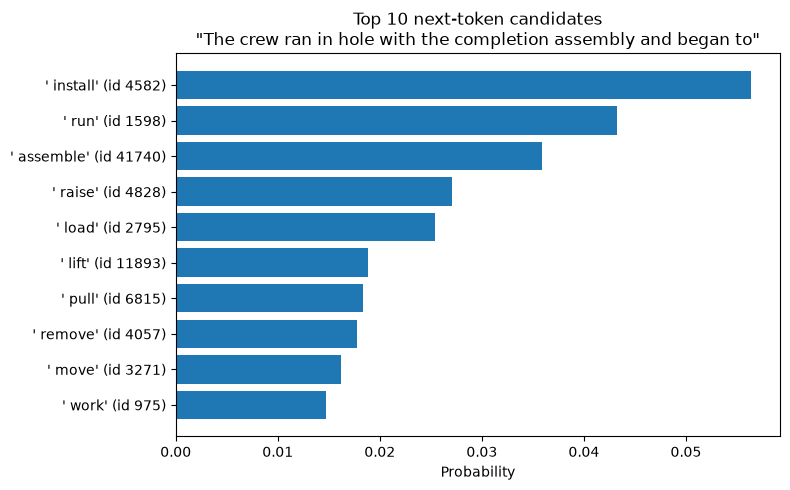


Uncertainty score for this sentence: 5.704
The model's single top pick:          ' install'


In [24]:
user_prompt = "The crew ran in hole with the completion assembly and began to"  # <-- change this line only

_, user_input_ids, user_decoded_tokens = tokenize_prompt(user_prompt)
print("Tokenization:")
show(pd.DataFrame({
    "position": range(len(user_input_ids)),
    "token_id": user_input_ids.tolist(),
    "decoded_token_repr": [repr(t) for t in user_decoded_tokens],
}))

user_top_tokens = get_top_tokens(user_prompt, n=10)
print("\nTop 10 next-token candidates:")
show(simple_view(user_top_tokens))

plot_top_tokens(user_top_tokens, f'Top 10 next-token candidates\n"{user_prompt}"')

_, _, user_probs = get_next_token_distribution(user_prompt)
print(f"\nUncertainty score for this sentence: {calculate_entropy(user_probs):.3f}")
print(f"The model's single top pick:          {user_top_tokens.iloc[0]['decoded_token']}")


## 15. Optional exercises

1. In Section 14, replace "completion assembly" with "PDC bit" and compare
   the top answers and uncertainty score to Section 4's result.
2. Take the main sentence and remove all operational context (just keep
   "prepared to run a new"). Does the uncertainty score go up, down, or
   stay about the same? Check Section 10's table for the real answer.
3. Try "RIH" (run in hole) in a drilling sentence vs. a completions
   sentence, the same way Section 9 did for POOH. Do the answers differ?
4. Break five more oilfield acronyms of your choice into pieces using
   `tokenize_term()` from Section 5a. Which ones split into the most
   pieces?
5. Write a deliberately ambiguous one-line oilfield sentence and run it
   through Section 14. Is the uncertainty score higher or lower than for
   prompt C?
6. In Section 11a, add one drilling sentence and one everyday sentence of
   your own to `bit_sentences` (each must end in "bit"). Where do they land
   on the map, and how do the three similarity numbers change?


## 16. Technical appendix (optional — skip if you like)

Nothing in this section is needed to understand the rest of the notebook.
It's here for anyone curious about exactly how this was run.

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [25]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Vocabulary size:      {model.config.vocab_size:,}")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Gensim version:       {gensim.__version__}  (word vectors in Section 11a: {GLOVE_NAME})")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float16
Vocabulary size:      151,936
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Gensim version:       4.4.0  (word vectors in Section 11a: glove-wiki-gigaword-100)
Random seed:          42


**Raw text vs. chat template.** Qwen2.5-1.5B-Instruct is an
instruction-tuned model, which normally expects input wrapped in a "chat
template" (extra hidden formatting used by chat-style AI tools). This
notebook deliberately used **raw, unwrapped text** instead, because it
makes the sentence-to-token mapping fully transparent — what you saw fed
into the tokenizer in Section 5 is exactly the text above, with nothing
hidden added on your behalf. Wrapping the same sentence in a chat template
would likely shift the model's answer, since it would then be predicting
"what an assistant says next" rather than "how does this sentence
continue" — that comparison is left for a follow-up notebook.

**Memory and performance notes.** This notebook only loads one model at a
time and uses a smaller numeric format on faster hardware (and a more
precise one on a plain CPU) to stay within the memory budget of a normal
laptop.
